In [206]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [207]:
import os
from pathlib import Path
Project_DIR = Path.cwd().parent

Data_DIR = Project_DIR / "data"/"processed"
df = pd.read_csv(Data_DIR / "Gurgaon_merged_v2.csv")
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,carpet_area,Plot_area,built_up_area,study room,servant room,pooja room,store room,others,furnishing_type,luxury_score
0,flat,maa bhagwati residency,sector 7,0.45,5000.0,900.0,Carpet area: 900 (83.61 sq.m.),2,2,1,...,900.0,NaN,NaN,0,0,0,0,0,0,28
1,flat,apna enclave,sector 5,0.50,7692.0,650.0,Carpet area: 650 (60.39 sq.m.),2,2,1,...,650.0,NaN,NaN,0,0,0,0,0,1,37
2,flat,tulsiani easy in homes,sector 48,0.40,6722.0,595.0,Carpet area: 595 (55.28 sq.m.),2,2,3,...,595.0,NaN,NaN,0,0,0,0,0,0,36
3,flat,smart world orchard,sector 61,1.47,12250.0,1200.0,Carpet area: 1200 (111.48 sq.m.),2,2,2,...,1200.0,NaN,NaN,1,0,0,0,0,0,76
4,flat,parkwood westend,sector 92,0.70,5204.0,1345.0,Super Built up area 1345(124.95 sq.m.),2,2,3,...,NaN,NaN,NaN,1,0,0,0,0,0,0


In [208]:
df[df.duplicated()]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,carpet_area,Plot_area,built_up_area,study room,servant room,pooja room,store room,others,furnishing_type,luxury_score
2616,flat,krisumi waterfall residences,sector 36a,2.30,15551.0,1479.0,Built Up area: 1479 (137.4 sq.m.),2,2,2,...,NaN,NaN,1479.0,0,0,0,0,0,0,0
2638,flat,smart world orchard,sector 61,2.41,14785.0,1630.0,Built Up area: 1630 (151.43 sq.m.)Carpet area:...,3,3,3,...,1625.0,NaN,1630.0,0,0,0,0,0,0,0
2640,flat,central park flower valley,sector-33 sohna,2.50,13270.0,1884.0,Carpet area: 1884 (175.03 sq.m.),3,3,2,...,1884.0,NaN,NaN,0,0,0,0,0,0,0
2664,flat,central park flower valley,sector-33 sohna,1.40,21538.0,650.0,Super Built up area 650(60.39 sq.m.),3,3,3,...,NaN,NaN,NaN,0,0,0,0,0,0,54


In [209]:
# See the actual duplicate pairs
duplicated_mask = df.duplicated(keep=False)
print(df[duplicated_mask].sort_values(by=['society', 'sector', 'price']))

# Count how many duplicates exist
print(f"Total duplicate rows: {df.duplicated().sum()}")

# Check if these 4 specific rows are actually marked as duplicates
# print(df.loc[[2616, 2638, 2640, 2664], 'duplicated'] = df.loc[[2616, 2638, 2640, 2664]].duplicated())

     property_type                       society           sector  price  \
2552          flat    central park flower valley  sector-33 sohna   1.40   
2664          flat    central park flower valley  sector-33 sohna   1.40   
2522          flat    central park flower valley  sector-33 sohna   2.50   
2640          flat    central park flower valley  sector-33 sohna   2.50   
2499          flat  krisumi waterfall residences       sector 36a   2.30   
2616          flat  krisumi waterfall residences       sector 36a   2.30   
2520          flat           smart world orchard        sector 61   2.41   
2638          flat           smart world orchard        sector 61   2.41   

      price_per_sqft    area  \
2552         21538.0   650.0   
2664         21538.0   650.0   
2522         13270.0  1884.0   
2640         13270.0  1884.0   
2499         15551.0  1479.0   
2616         15551.0  1479.0   
2520         14785.0  1630.0   
2638         14785.0  1630.0   

                          

In [210]:
df.drop_duplicates(inplace=True)

In [211]:
df.duplicated().sum()

np.int64(0)

In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3957 entries, 0 to 3960
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3957 non-null   object 
 1   society              3957 non-null   object 
 2   sector               3957 non-null   object 
 3   price                3937 non-null   float64
 4   price_per_sqft       3937 non-null   float64
 5   area                 3937 non-null   float64
 6   areaWithType         3957 non-null   object 
 7   bedRoom              3957 non-null   int64  
 8   bathroom             3957 non-null   int64  
 9   balcony              3957 non-null   object 
 10  floorNum             3933 non-null   float64
 11  facing               2783 non-null   object 
 12  agePossession        3957 non-null   object 
 13  description          3957 non-null   object 
 14  rating               3511 non-null   object 
 15  super_built_up_area  1933 non-null   float6

In [213]:
df.shape

(3957, 26)

In [214]:
df.isnull().sum()

property_type             0
society                   0
sector                    0
price                    20
price_per_sqft           20
area                     20
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 24
facing                 1174
agePossession             0
description               0
rating                  446
super_built_up_area    2024
carpet_area            1956
Plot_area              3190
built_up_area          2726
study room                0
servant room              0
pooja room                0
store room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

In [215]:
df = df[~df.price.isnull()]

In [216]:
df.price.isnull().sum()

np.int64(0)

In [217]:
df.isnull().sum()

property_type             0
society                   0
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 24
facing                 1168
agePossession             0
description               0
rating                  444
super_built_up_area    2004
carpet_area            1939
Plot_area              3187
built_up_area          2711
study room                0
servant room              0
pooja room                0
store room                0
others                    0
furnishing_type           0
luxury_score              0
dtype: int64

In [218]:
df.floorNum.isnull().sum()

np.int64(24)

In [219]:
df[df.floorNum.isnull()]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,carpet_area,Plot_area,built_up_area,study room,servant room,pooja room,store room,others,furnishing_type,luxury_score
180,flat,experion heartsong,sector 102,1.08,6150.0,1756.0,Built Up area: 1758 (163.32 sq.m.),3,3,0,...,NaN,NaN,1758.0,0,0,0,0,0,0,0
212,flat,"ganpati apartment 2, laxman vihar phase 1",laxman vihar,0.45,4705.0,956.0,Carpet area: 850 (78.97 sq.m.),2,2,1,...,850.00000,NaN,NaN,0,0,0,0,0,0,46
2076,flat,huda housing board society,sector 52,0.45,9745.0,462.0,Carpet area: 461.77 (42.9 sq.m.),1,1,0,...,461.77131,NaN,NaN,0,0,1,0,0,1,43
2758,flat,independent,sector 78,0.60,3692.0,1625.0,Built Up area: 1625 (150.97 sq.m.),2,2,0,...,NaN,NaN,1625.0,0,0,0,0,0,0,0
2911,flat,apna enclave,sector 5,0.80,6153.0,1300.0,Super Built up area 1300(120.77 sq.m.)Built Up...,3,3,1,...,NaN,NaN,1000.0,0,0,0,0,0,0,0
3020,house,vipul tatvam villa,sector 48,8.50,26235.0,3240.0,Plot area 360(301.01 sq.m.),4,4,2,...,NaN,360.0,NaN,0,1,1,1,0,0,88
3048,house,independent,sector 1,5.60,17284.0,3240.0,Plot area 360(301.01 sq.m.),8,6,3+,...,NaN,360.0,NaN,1,1,1,1,0,0,0
3125,house,independent,dlf phase 3,1.45,26852.0,540.0,Plot area 60(50.17 sq.m.),3,3,1,...,NaN,60.0,NaN,0,0,0,0,0,0,9
3174,house,independent,sector 5,1.50,10288.0,1458.0,Plot area 162(135.45 sq.m.)Built Up area: 210 ...,3,3,0,...,NaN,162.0,210.0,0,0,0,0,0,0,0
3192,house,independent,laxman vihar phase 2,4.12,8889.0,4635.0,Plot area 515(430.61 sq.m.),2,1,3+,...,NaN,515.0,NaN,0,0,0,0,0,0,0


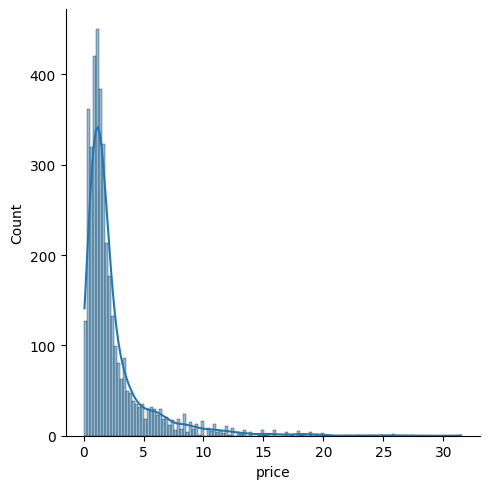

In [220]:
# Checking Outliers in the price column
sns.displot(df.price, kde=True)

<Axes: xlabel='price'>

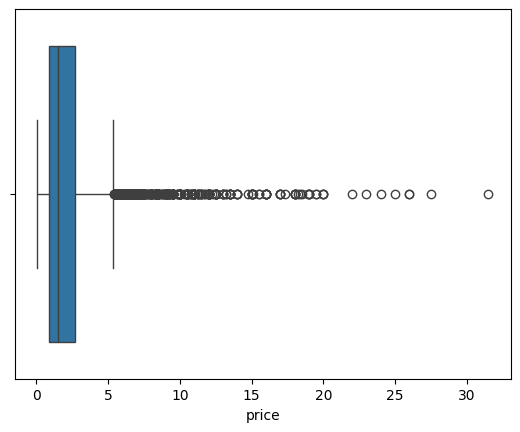

In [221]:
sns.boxplot(x=df.price)

In [222]:
Q1 = df.price.quantile(0.25)
Q3 = df.price.quantile(0.75)
# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Calculate the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers in the price column
outliers_area = df[(df.price < lower_bound) | (df.price > upper_bound)]
outliers_count = outliers_area.shape[0]
print(f"Number of outliers in the price column: {outliers_count}")
print(outliers_area.price.describe())

Number of outliers in the price column: 443
count    443.000000
mean       9.152799
std        4.046645
min        5.400000
25%        6.300000
50%        8.000000
75%       10.550000
max       31.500000
Name: price, dtype: float64


In [223]:
outliers_area.sort_values(by='price', ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,carpet_area,Plot_area,built_up_area,study room,servant room,pooja room,store room,others,furnishing_type,luxury_score
3869,house,arjun marg/ sector- 26 phase- 1/ golf course road,sector 26,31.50,35000.0,9000.0,Plot area 1000(836.13 sq.m.),7,9,3+,...,NaN,1000.0,NaN,1,1,1,1,0,2,74
3630,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,...,NaN,1254.0,NaN,1,1,1,0,1,1,42
3621,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,...,350.0,402.0,400.00,1,1,1,1,0,2,72
3663,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,...,NaN,505.0,NaN,1,1,1,0,1,1,138
3808,house,suncity township,sector 54,25.00,31111.0,8036.0,Plot area 1000(836.13 sq.m.),4,4,3+,...,NaN,1000.0,NaN,1,1,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1991,flat,raheja atlantis,sector 31,5.50,18688.0,2943.0,Super Built up area 2943(273.41 sq.m.),4,5,3+,...,NaN,NaN,NaN,1,1,1,0,0,0,81
420,flat,experion windchants,sector 112,5.49,11584.0,4739.0,Super Built up area 4739(440.27 sq.m.)Built Up...,4,5,3+,...,NaN,NaN,3655.35,0,1,0,0,0,1,168
3027,house,ansal api esencia,sector 67,5.46,24170.0,2259.0,Plot area 251(209.87 sq.m.),4,5,3+,...,NaN,251.0,NaN,1,0,1,1,0,1,103
3045,house,bptp visionnaire,sector 70a,5.40,20690.0,2610.0,Plot area 290(242.48 sq.m.),4,5,3+,...,NaN,290.0,NaN,1,1,1,1,0,1,136


# Price_per_sqft

<Axes: xlabel='price_per_sqft'>

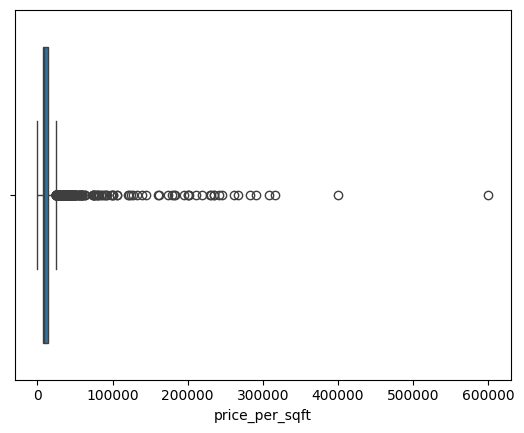

In [224]:
# check outliers in the price_sqft column
sns.boxplot(x = df.price_per_sqft)

<Axes: xlabel='price_per_sqft', ylabel='Count'>

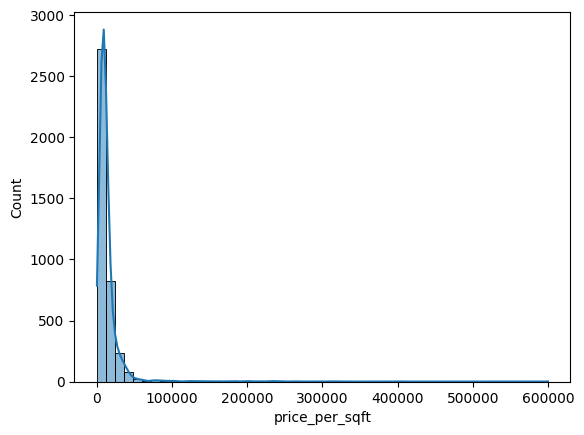

In [225]:
sns.histplot(x = df.price_per_sqft, bins=50, kde=True)

In [226]:
Q1 =df.price_per_sqft.quantile(0.25)
Q2 = df.price_per_sqft.quantile(0.75)

IQR = Q2 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q2 + 1.5 * IQR

outliers_sqft = df[(df.price_per_sqft < lower_bound) | (df.price_per_sqft > upper_bound)]
outliers_sqft_count = outliers_sqft.shape[0]
print(f"Number of outliers in the price_per_sqft column: {outliers_sqft_count}")
print(outliers_sqft.price_per_sqft.describe())

Number of outliers in the price_per_sqft column: 384
count       384.000000
mean      53242.989583
std       60296.525361
min       24202.000000
25%       27778.000000
50%       33368.500000
75%       43102.000000
max      600000.000000
Name: price_per_sqft, dtype: float64


In [227]:
outliers_sqft.sort_values(by='price_per_sqft', ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,carpet_area,Plot_area,built_up_area,study room,servant room,pooja room,store room,others,furnishing_type,luxury_score
3586,house,emaar the palm springs,sector 54,24.00,600000.0,400.0,Plot area 400(37.16 sq.m.),5,5,2,...,NaN,400.0,NaN,1,1,1,0,0,1,122
3626,house,dlf city plots phase 2,sector 25,10.00,400000.0,250.0,Plot area 250(23.23 sq.m.),12,12,3+,...,NaN,250.0,NaN,1,1,0,0,0,1,114
3312,house,independent,sector 12,6.00,315789.0,190.0,Plot area 190(17.65 sq.m.)Carpet area: 1600 sq...,9,6,2,...,1600.0,190.0,NaN,0,0,0,0,0,0,0
3534,house,ansal,c block sushant lok phase 1,1.85,308333.0,60.0,Plot area 60(5.57 sq.m.),8,8,3+,...,NaN,60.0,NaN,0,0,0,0,0,0,53
3886,house,uppal southend,sector 49,6.75,290948.0,232.0,Plot area 232(21.55 sq.m.),12,12,3+,...,NaN,232.0,NaN,1,1,1,0,1,1,49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27,flat,central park resort belgravia residences,sector 48,6.25,24300.0,2572.0,Carpet area: 2880 (267.56 sq.m.),3,5,3+,...,2880.0,NaN,NaN,0,1,0,0,0,1,49
3093,house,international city by sobha phase 1,sector 109,5.90,24280.0,2430.0,Plot area 270(225.75 sq.m.),4,5,2,...,NaN,270.0,NaN,0,1,0,0,0,1,111
3133,house,independent,sector 17a,3.93,24214.0,1623.0,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19,17,3,...,NaN,1623.0,1622.0,1,1,1,1,0,0,74
655,flat,m3m golfestate,sector 65,5.30,24211.0,2189.0,Super Built up area 2850(264.77 sq.m.)Carpet a...,3,3,3,...,2189.0,NaN,NaN,0,1,0,0,0,2,49


In [228]:
# outliers_sqft.to_csv(Data_DIR / "outliers_sqft.csv", index=False)

In [229]:
# A 400 sqft house selling for 24 crore is absurd. But 400 isn't square feet — 
# it's the plot area in square yards (the areaWithType confirms it: "Plot area 400"). 400 sq.yards ≈ 3,600 sqft. 
# The price is being divided by a number that's roughly 9× too small, 
# so price_per_sqft explodes by ~9×.

In [230]:
outliers_sqft.area = outliers_sqft.area.apply(lambda x: x*9 if x < 1000 else x)

C:\Users\Admin\AppData\Local\Temp\ipykernel_5068\3811434196.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft.area = outliers_sqft.area.apply(lambda x: x*9 if x < 1000 else x)


In [231]:
outliers_sqft.price_per_sqft = outliers_sqft.price * 10000000 / outliers_sqft.area

C:\Users\Admin\AppData\Local\Temp\ipykernel_5068\2469457961.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft.price_per_sqft = outliers_sqft.price * 10000000 / outliers_sqft.area


In [232]:
outliers_sqft.price_per_sqft.describe()

count      384.000000
mean     28463.627142
std      12608.037885
min       2689.157805
25%      24691.358025
50%      29183.501684
75%      35240.436232
max      82539.682540
Name: price_per_sqft, dtype: float64

In [233]:
df.update(outliers_sqft)

<Axes: xlabel='price_per_sqft'>

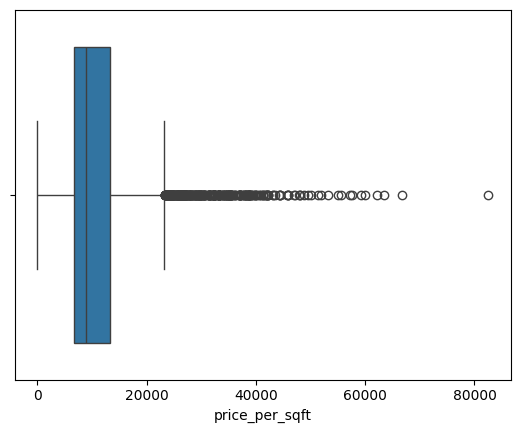

In [234]:
sns.boxplot(x = df.price_per_sqft)

In [235]:
df[df.price_per_sqft > 50000].shape

(13, 26)

In [236]:
df = df[df.price_per_sqft <= 50000]

<Axes: xlabel='price_per_sqft'>

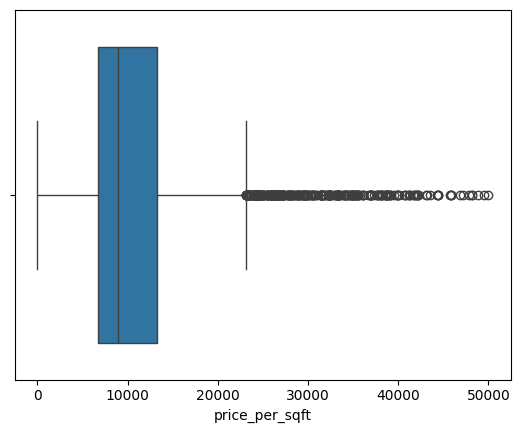

In [237]:
sns.boxplot(x=df.price_per_sqft)

# AREA

<Axes: xlabel='area', ylabel='Count'>

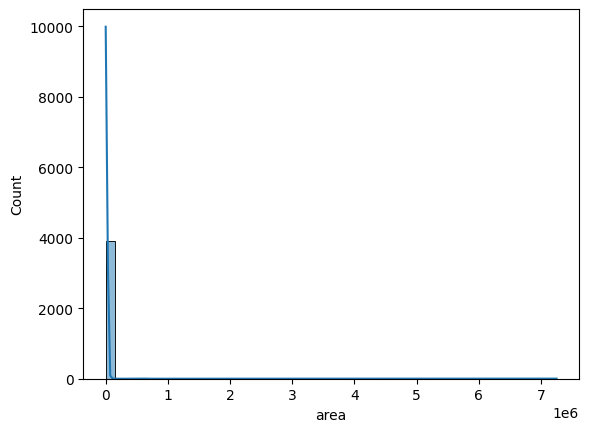

In [238]:
sns.histplot(x = df.area, bins=50, kde=True)

<Axes: xlabel='area'>

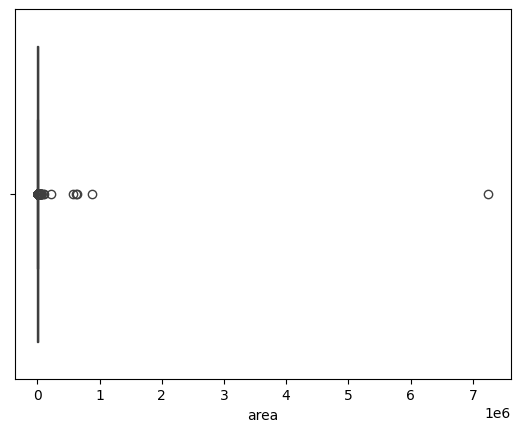

In [239]:
sns.boxplot(x = df.area)

In [240]:
df[df.area > 100000].sort_values(by='area', ascending=False)
df = df[df['area'] < 100000]

In [241]:
Q1 = df.area.quantile(0.25)
Q3 = df.area.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_area = df[(df.area < lower_bound) | (df.area > upper_bound)]
print(f"Number of outliers in the area column: {outliers_area.shape[0]}")
print(outliers_area.area.describe())

Number of outliers in the area column: 247
count      247.000000
mean      8510.497976
std      12490.056911
min       3980.000000
25%       4500.000000
50%       4950.000000
75%       6500.000000
max      98978.000000
Name: area, dtype: float64


In [242]:
outliers_area

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,carpet_area,Plot_area,built_up_area,study room,servant room,pooja room,store room,others,furnishing_type,luxury_score
30,flat,ompee k s residency,sector 1,1.60,2992.891882,5346.0,Carpet area: 66 (55.18 sq.m.),2,2,2,...,66.0,NaN,NaN,0,0,0,0,0,0,0
81,flat,pyramid elite,sector 86,0.46,79.000000,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,...,58141.0,NaN,NaN,0,0,0,0,0,0,15
82,flat,emaar mgf palm terraces,sector 66,4.50,10599.000000,4246.0,Super Built up area 3670(340.95 sq.m.),5,5,3+,...,NaN,NaN,NaN,0,1,0,0,0,0,105
142,flat,vatika sovereign next sector-82 a gurgaon,sector 82a,2.91,6700.000000,4343.0,Super Built up area 4350(404.13 sq.m.)Carpet a...,4,4,3,...,3480.0,NaN,NaN,1,1,0,1,0,1,79
172,flat,palam vihar society,sector 1,3.35,7444.000000,4500.0,Carpet area: 4500 (418.06 sq.m.),4,4,3+,...,4500.0,NaN,NaN,1,0,0,0,0,0,66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3928,house,unitech uniworld resorts,sector 33,11.75,23240.000000,5056.0,Plot area 502(419.74 sq.m.),5,7,3+,...,NaN,502.0,NaN,0,1,0,0,0,0,80
3932,house,unitech uniworld resorts,sector 33,11.00,26666.666667,4125.0,Plot area 500(418.06 sq.m.),5,6,3,...,NaN,500.0,NaN,1,1,0,0,0,0,58
3944,house,independent,sector 46,2.40,2962.962963,8100.0,Plot area 100(83.61 sq.m.),4,4,3,...,NaN,100.0,NaN,0,0,0,1,0,1,44
3948,house,independent,sector 46,2.20,2689.157805,8181.0,Plot area 101(84.45 sq.m.),3,3,2,...,NaN,101.0,NaN,0,0,0,1,0,1,56


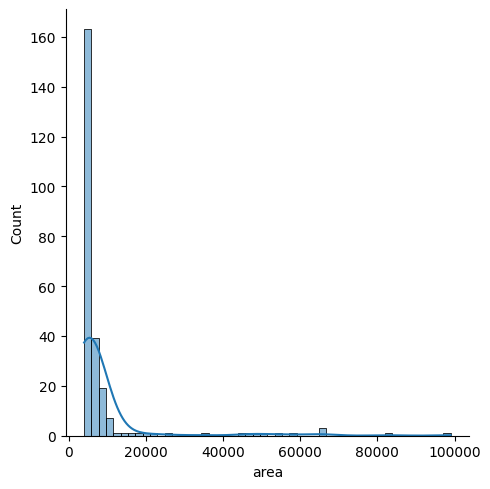

In [243]:
sns.displot(outliers_area.area, bins=50, kde=True)
plt.show()

<Axes: xlabel='area'>

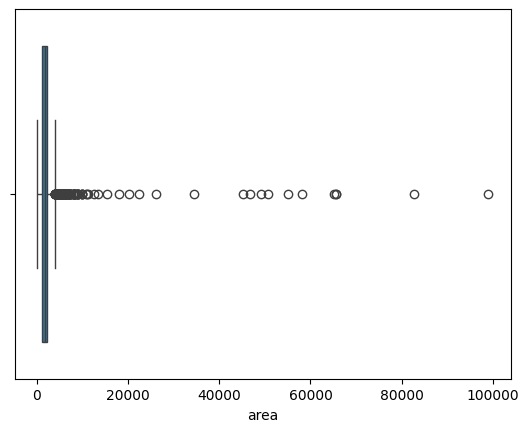

In [244]:
sns.boxplot(x = df.area)

In [245]:
df[df.area > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,carpet_area,Plot_area,built_up_area,study room,servant room,pooja room,store room,others,furnishing_type,luxury_score
81,flat,pyramid elite,sector 86,0.46,79.000000,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,...,58141.00,NaN,NaN,0,0,0,0,0,0,15
1305,flat,ramsons kshitij,sector 95,0.24,53.000000,45283.0,Carpet area: 45966 (4270.38 sq.m.),2,2,1,...,45966.00,NaN,NaN,0,0,0,0,1,0,33
1308,flat,rof ananda,sector 95,0.33,60.000000,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,...,54917.00,NaN,NaN,0,0,0,0,0,0,37
1309,flat,rof ananda,sector 95,0.38,58.000000,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,...,64412.00,NaN,NaN,0,0,0,0,0,0,51
1310,flat,rof ananda,sector 95,0.21,61.000000,34426.0,Carpet area: 34401 (3195.96 sq.m.),1,1,1,...,34401.00,NaN,NaN,0,0,0,0,0,0,68
1431,flat,signature the serenas,sector 48,0.28,57.000000,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,...,48811.00,NaN,NaN,1,0,0,0,0,0,37
1639,flat,m3m golfestate,sector 65,13.20,12000.000000,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,...,11000.00,NaN,NaN,0,1,0,0,0,0,60
2334,flat,rof ananda,sector 95,0.38,58.000000,65517.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2,...,64529.00,NaN,NaN,1,0,0,0,0,0,15
2434,flat,godrej air,sector 85,2.50,1379.000000,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,...,18122.00,NaN,NaN,1,0,1,0,1,1,44
2852,flat,godrej icon,sector 88a,1.75,1384.000000,12645.0,Carpet area: 1175.11,3,3,3+,...,1175.11,NaN,NaN,0,0,0,0,0,0,0


In [246]:
df.loc[3102, 'area'] = 1500
df.loc[3109, 'area'] = 3100
df.loc[3116, 'area'] = 2160
df.loc[3329, 'area'] = 115 * 9
df.loc[3409, 'area'] = 7250
df.loc[3564, 'area'] = 3500
df.loc[3616, 'area'] = 5800
df.loc[3630, 'area'] = 1254

In [247]:
df.loc[2852, 'area'] = 1175

In [248]:
df.drop(index=[
    81, 1305, 1308, 1309, 1310,
    1431, 2334, 3679, 3706, 3761
], inplace=True, errors='ignore')

In [249]:
df = df[df.area < 10000]

<Axes: xlabel='area'>

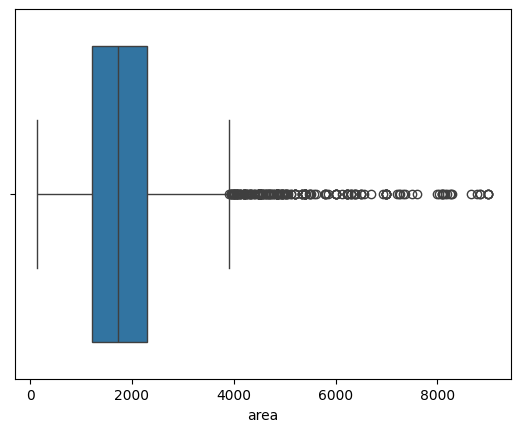

In [250]:
sns.boxplot(x = df.area)

# BEDROOM

In [251]:
df.bedRoom.isnull().sum()

np.int64(0)

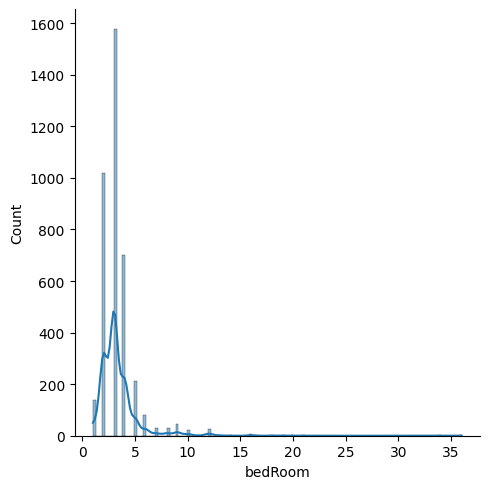

In [252]:
sns.displot(x= df.bedRoom, kde = True)

<Axes: xlabel='bedRoom'>

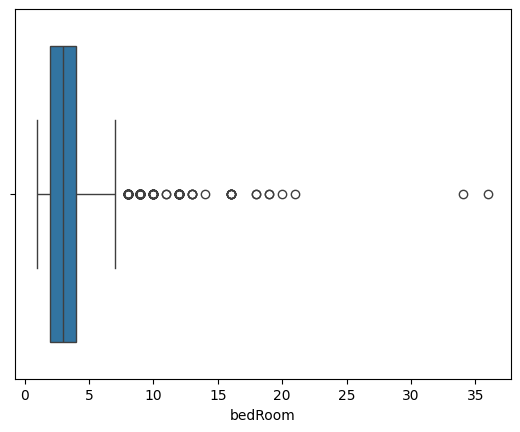

In [253]:
sns.boxplot(x = df.bedRoom)

In [254]:
Q1 = df.bedRoom.quantile(0.25)
Q3 = df.bedRoom.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_bedRoom = df[(df.bedRoom < lower_bound) | (df.bedRoom > upper_bound)]
print(f"Number of outliers in the bedRoom column: {outliers_bedRoom.shape[0]}")
print(outliers_bedRoom.bedRoom.describe())

Number of outliers in the bedRoom column: 144
count    144.000000
mean      10.770833
std        3.971434
min        8.000000
25%        9.000000
50%        9.000000
75%       12.000000
max       36.000000
Name: bedRoom, dtype: float64


In [255]:
outliers_bedRoom.sort_values(by='bedRoom', ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,carpet_area,Plot_area,built_up_area,study room,servant room,pooja room,store room,others,furnishing_type,luxury_score
3204,house,independent,sector 12A,2.25,6944.000000,3240.0,Plot area 360(301.01 sq.m.),36,36,2,...,NaN,360.0,NaN,0,1,0,0,0,0,7
3263,house,manohar nagar,sector 8,5.60,12444.000000,4500.0,Plot area 500(418.06 sq.m.)Built Up area: 500 ...,34,34,3+,...,NaN,500.0,500.0,0,0,0,0,0,1,0
3000,house,independent,sector 54,5.00,43066.322136,1161.0,Plot area 129(107.86 sq.m.),21,21,3+,...,NaN,129.0,NaN,0,1,0,0,0,2,49
3002,house,independent,sector 43,4.50,39062.500000,1152.0,Plot area 128(107.02 sq.m.),20,20,3+,...,NaN,128.0,NaN,0,1,0,0,0,2,22
3133,house,independent,sector 17a,3.93,24214.417745,1623.0,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19,17,3,...,NaN,1623.0,1622.0,1,1,1,1,0,0,74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3672,house,independent,sector 46,4.35,23693.000000,1836.0,Plot area 204(170.57 sq.m.),8,8,2,...,NaN,204.0,NaN,1,0,1,0,0,1,19
3705,house,independent,b1 block sector 57,3.70,25534.851622,1449.0,Plot area 161(134.62 sq.m.),8,8,2,...,NaN,161.0,NaN,0,0,1,0,0,1,49
3710,house,independent,sector 49,4.50,15625.000000,2880.0,Plot area 320(267.56 sq.m.),8,8,3,...,NaN,320.0,NaN,1,1,1,1,0,2,151
3718,house,independent,sector 10a,3.60,19608.000000,1836.0,Plot area 204(170.57 sq.m.),8,4,3,...,NaN,204.0,NaN,0,0,1,0,0,1,28


In [256]:
df = df[df.bedRoom <= 10]

In [257]:
df.shape

(3853, 26)

In [258]:
df.drop(columns=['areaWithType','description','rating'], inplace=True, errors='ignore')

In [259]:
df.shape

(3853, 23)

In [260]:
Q1 = df.bedRoom.quantile(0.25)
Q3 = df.bedRoom.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_bedRoom = df[(df.bedRoom < lower_bound) | (df.bedRoom > upper_bound)]
print(f"Number of outliers in the bedRoom column: {outliers_bedRoom.shape[0]}")
print(outliers_bedRoom.bedRoom.describe())

Number of outliers in the bedRoom column: 96
count    96.000000
mean      8.895833
std       0.732396
min       8.000000
25%       8.000000
50%       9.000000
75%       9.000000
max      10.000000
Name: bedRoom, dtype: float64


In [261]:
outliers_bedRoom.shape

(96, 23)

<Axes: xlabel='bedRoom'>

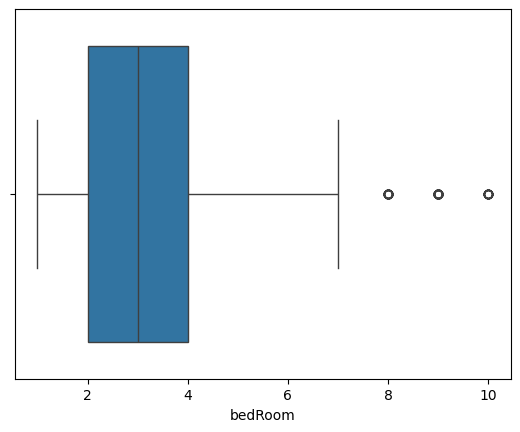

In [262]:
sns.boxplot(x = df.bedRoom)

# BATHROOM

In [263]:
df.bathroom.isnull().sum()

np.int64(0)

<Axes: xlabel='bathroom'>

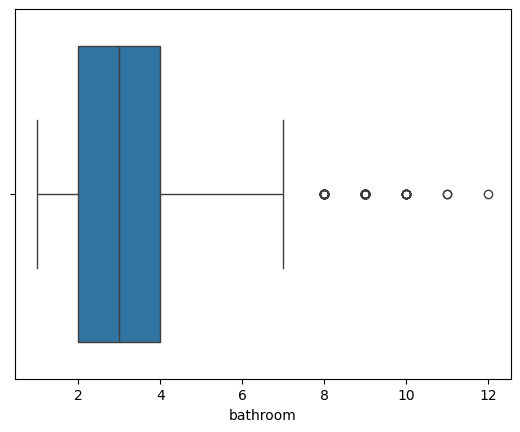

In [264]:
sns.boxplot(x = df.bathroom)

In [265]:
df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area',
       'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing', 'agePossession',
       'super_built_up_area', 'carpet_area', 'Plot_area', 'built_up_area',
       'study room', 'servant room', 'pooja room', 'store room', 'others',
       'furnishing_type', 'luxury_score'],
      dtype='object')

<Axes: xlabel='built_up_area'>

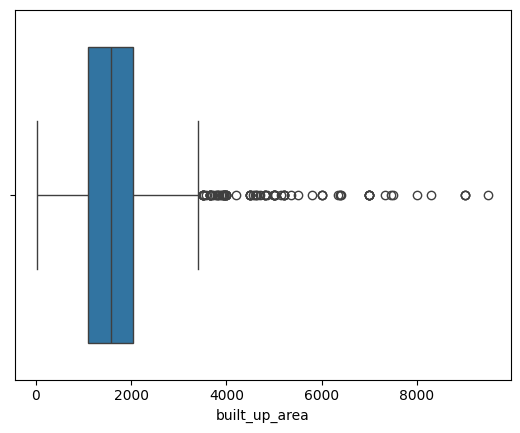

In [266]:
sns.boxplot(x = df.built_up_area)

<Axes: xlabel='super_built_up_area'>

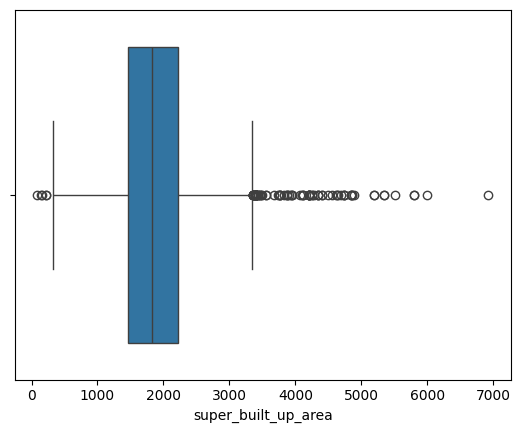

In [267]:
sns.boxplot(x = df.super_built_up_area)

<Axes: xlabel='carpet_area'>

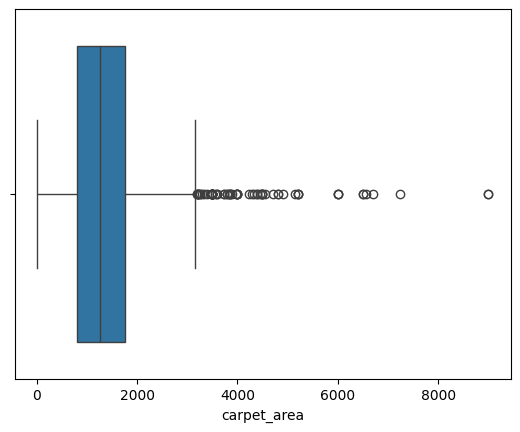

In [268]:
sns.boxplot(x = df.carpet_area)

In [269]:
Q1 = df.carpet_area.quantile(0.25)
Q3 = df.carpet_area.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_carpet_area = df[(df.carpet_area < lower_bound) | (df.carpet_area > upper_bound)]
print(f"Number of outliers in the carpet_area column: {outliers_carpet_area.shape[0]}")
print(outliers_carpet_area.carpet_area.describe())

Number of outliers in the carpet_area column: 67
count      67.000000
mean     4392.134328
std      1279.463700
min      3200.000000
25%      3500.000000
50%      3980.000000
75%      4750.000000
max      9000.000000
Name: carpet_area, dtype: float64


In [270]:
outliers_carpet_area

,property_type,society,sector,price,price_per_sqft,area,bedRoom,bathroom,balcony,floorNum,...,carpet_area,Plot_area,built_up_area,study room,servant room,pooja room,store room,others,furnishing_type,luxury_score
142,flat,vatika sovereign next sector-82 a gurgaon,sector 82a,2.91,6700.000000,4343.0,4,4,3,6.0,...,3480.0,NaN,NaN,1,1,0,1,0,1,79
172,flat,palam vihar society,sector 1,3.35,7444.000000,4500.0,4,4,3+,2.0,...,4500.0,NaN,NaN,1,0,0,0,0,0,66
218,flat,vatika sovereign next,sector 82a,3.85,7500.000000,5133.0,5,6,3+,6.0,...,5140.0,NaN,NaN,0,1,1,0,0,0,148
287,flat,m3m golfestate,sector 65,6.15,15998.000000,3844.0,3,5,3+,1.0,...,3844.0,NaN,NaN,0,1,0,0,0,2,49
290,flat,jmd gardens,sector 33,3.25,7510.000000,4328.0,4,4,3+,17.0,...,4328.0,NaN,NaN,0,1,0,0,0,1,130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3828,house,emaar mgf marbella,sector 66,19.00,31666.666667,6000.0,5,6,3+,3.0,...,6000.0,9000.0,NaN,0,1,1,1,0,1,110
3873,house,emaar mgf marbella,sector 66,9.00,21251.000000,4235.0,4,4,3+,NaN,...,4235.0,5605.0,5200.0,0,1,1,1,0,1,114
3898,house,independent,sector 25,10.00,37037.037037,2700.0,5,5,3+,3.0,...,9000.0,2700.0,9500.0,0,1,1,0,0,2,29
3934,house,unitech espace,sector 50,7.45,34490.740741,2160.0,4,4,3,3.0,...,4000.0,240.0,4500.0,0,1,0,0,0,1,59


In [271]:
df.shape

(3853, 23)

In [272]:
from pathlib import Path

output_path = Path("../Data/processed/Gurgaon_merged_v3.csv")
df.to_csv(output_path, index=False)